# Rolling Temporal Stability Gate

This section implements the temporal-stability diagnostic. The routing rule is fixed from historical training windows before evaluation on the held-out test split.


In [1]:
from pathlib import Path
import gc
import math
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import trim_mean

warnings.filterwarnings("ignore")

SEED = 2026
rng = np.random.default_rng(SEED)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


NumPy: 1.22.3
Pandas: 1.4.1


## 1. Fixed experimental protocol


In [2]:
PROJECT_ROOT = Path("/data/code/2026_08")

OUTPUT_DIR = (
    PROJECT_ROOT
    / "results_rolling_temporal_stability_gate"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

SEQ_LEN = 96

PEMS_HORIZONS = [12, 24, 48]
GENERAL_HORIZONS = [96, 192, 336, 720]

MAX_TOPK = 10

MAX_TARGET_CHANNELS = 32
MAX_SOURCE_CANDIDATES = 128

MAX_TRAIN_ORIGINS = 5000
MAX_TEST_ORIGINS = 3000

# 5 chronological blocks:
# B1 -> B2, B1+B2 -> B3, ... -> B5
N_ROLL_BLOCKS = 5

# Primary pre-declared stability rule.
MIN_POSITIVE_RATE = 0.60
MIN_MEDIAN_GAIN = 0.0

TEACHER_FIT_FRACTION = 0.70

RIDGE_LAMBDA = 1e-3
SOURCE_RIDGE_LAMBDA = 1e-2

BOOTSTRAP_REPS = 2000
TRIM_PROPORTION = 0.10

print("OUTPUT_DIR:", OUTPUT_DIR)
print("N_ROLL_BLOCKS:", N_ROLL_BLOCKS)
print("MIN_POSITIVE_RATE:", MIN_POSITIVE_RATE)
print("MAX_TOPK:", MAX_TOPK)


OUTPUT_DIR: /data/code/2026_08/results_rolling_temporal_stability_gate
N_ROLL_BLOCKS: 5
MIN_POSITIVE_RATE: 0.6
MAX_TOPK: 10


## 2. Dataset registry


In [3]:
DATASET_REGISTRY = {
    "PeMS03": {
        "family": "PeMS",
        "horizons": PEMS_HORIZONS,
        "paths": [
            "/data/dataset/PeMS03.npz",
            "/data/dataset/PEMS03/PEMS03.npz",
            "/data/dataset/PEMS03.npz",
            "/data/dataset/pems/PeMS03.npz",
        ],
    },
    "PeMS04": {
        "family": "PeMS",
        "horizons": PEMS_HORIZONS,
        "paths": [
            "/data/dataset/PeMS04.npz",
            "/data/dataset/PEMS04/PEMS04.npz",
            "/data/dataset/PEMS04.npz",
            "/data/dataset/pems/PeMS04.npz",
        ],
    },
    "PeMS07": {
        "family": "PeMS",
        "horizons": PEMS_HORIZONS,
        "paths": [
            "/data/dataset/PeMS07.npz",
            "/data/dataset/PEMS07/PEMS07.npz",
            "/data/dataset/pems/PeMS07.npz",
        ],
    },
    "PeMS08": {
        "family": "PeMS",
        "horizons": PEMS_HORIZONS,
        "paths": [
            "/data/dataset/PeMS08.npz",
            "/data/dataset/PEMS08/PEMS08.npz",
            "/data/dataset/pems/PeMS08.npz",
        ],
    },
    "Electricity": {
        "family": "General",
        "horizons": GENERAL_HORIZONS,
        "paths": [
            "/data/dataset/electricity/electricity.csv",
            "/data/dataset/electricity.csv",
        ],
    },
    "Weather": {
        "family": "General",
        "horizons": GENERAL_HORIZONS,
        "paths": [
            "/data/dataset/weather/weather.csv",
            "/data/dataset/weather.csv",
        ],
    },
    "Solar": {
        "family": "General",
        "horizons": GENERAL_HORIZONS,
        "paths": [
            "/data/dataset/solar/solar_AL.txt",
            "/data/dataset/solar_AL.txt",
        ],
    },
    "ETTh1": {
        "family": "General",
        "horizons": GENERAL_HORIZONS,
        "paths": [
            "/data/dataset/ETT-small/ETTh1.csv",
            "/data/dataset/ETTh1.csv",
        ],
    },
    "ETTm1": {
        "family": "General",
        "horizons": GENERAL_HORIZONS,
        "paths": [
            "/data/dataset/ETT-small/ETTm1.csv",
            "/data/dataset/ETTm1.csv",
        ],
    },
}


def resolve_path(candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    return None


rows = []

for name, spec in DATASET_REGISTRY.items():
    p = resolve_path(
        spec["paths"]
    )

    rows.append(
        {
            "dataset": name,
            "family": spec["family"],
            "path": None if p is None else str(p),
            "found": p is not None,
            "horizons": str(spec["horizons"]),
        }
    )

path_df = pd.DataFrame(rows)

display(path_df)

if not path_df["found"].all():
    print(
        "\nSome datasets are missing. "
        "Edit DATASET_REGISTRY paths before the main run."
    )


,dataset,family,path,found,horizons
0,PeMS03,PeMS,/data/dataset/PeMS03.npz,True,"[12, 24, 48]"
1,PeMS04,PeMS,/data/dataset/PeMS04.npz,True,"[12, 24, 48]"
2,PeMS07,PeMS,/data/dataset/PeMS07.npz,True,"[12, 24, 48]"
3,PeMS08,PeMS,/data/dataset/PeMS08.npz,True,"[12, 24, 48]"
4,Electricity,General,/data/dataset/electricity/electricity.csv,True,"[96, 192, 336, 720]"
5,Weather,General,/data/dataset/weather/weather.csv,True,"[96, 192, 336, 720]"
6,Solar,General,/data/dataset/solar/solar_AL.txt,True,"[96, 192, 336, 720]"
7,ETTh1,General,/data/dataset/ETT-small/ETTh1.csv,True,"[96, 192, 336, 720]"
8,ETTm1,General,/data/dataset/ETT-small/ETTm1.csv,True,"[96, 192, 336, 720]"


## 3. Effective K rule


In [4]:
def effective_topk(C):
    return int(
        max(
            1,
            min(
                MAX_TOPK,
                math.ceil(
                    (C - 1) / 2
                ),
            ),
        )
    )


for C in [
    7,
    21,
    137,
    321,
    358,
    883,
]:
    print(
        f"C={C:4d} -> K={effective_topk(C)}"
    )


C=   7 -> K=3
C=  21 -> K=10
C= 137 -> K=10
C= 321 -> K=10
C= 358 -> K=10
C= 883 -> K=10


## 4. Load and normalize raw series


In [5]:
def load_series(
    dataset_name,
    path,
):
    path = Path(path)

    if path.suffix.lower() == ".npz":
        obj = np.load(path)

        if "data" in obj:
            x = obj["data"]
        else:
            x = obj[list(obj.keys())[0]]

        if x.ndim == 3:
            x = x[:, :, 0]

        if x.ndim != 2:
            raise ValueError(
                f"{dataset_name}: unexpected shape {x.shape}"
            )

        x = x.astype(np.float32)

    elif path.suffix.lower() == ".csv":
        df = pd.read_csv(path)

        date_col = None

        for candidate in [
            "date",
            "datetime",
            "timestamp",
            "time",
        ]:
            if candidate in df.columns:
                date_col = candidate
                break

        if date_col is None:
            first = df.columns[0]

            if not pd.api.types.is_numeric_dtype(
                df[first]
            ):
                date_col = first

        if date_col is not None:
            df = df.drop(
                columns=[date_col]
            )

        df = df.select_dtypes(
            include=[np.number]
        )

        x = df.to_numpy(
            dtype=np.float32
        )

    else:
        try:
            x = np.loadtxt(
                path,
                delimiter=",",
                dtype=np.float32,
            )
        except Exception:
            x = np.loadtxt(
                path,
                dtype=np.float32,
            )

        if x.ndim == 1:
            x = x[:, None]

    if x.ndim != 2:
        raise ValueError(
            f"{dataset_name}: expected [T,C], got {x.shape}"
        )

    if not np.isfinite(x).all():
        raise ValueError(
            f"{dataset_name}: non-finite values"
        )

    return x


def split_boundaries(
    dataset_name,
    T,
):
    if dataset_name == "ETTh1":
        train_end = 12 * 30 * 24
        val_end = train_end + 4 * 30 * 24
        test_end = val_end + 4 * 30 * 24

        return (
            min(train_end, T),
            min(val_end, T),
            min(test_end, T),
        )

    if dataset_name == "ETTm1":
        unit = 30 * 24 * 4

        train_end = 12 * unit
        val_end = train_end + 4 * unit
        test_end = val_end + 4 * unit

        return (
            min(train_end, T),
            min(val_end, T),
            min(test_end, T),
        )

    return (
        int(0.70 * T),
        int(0.80 * T),
        T,
    )


def standardize_train_only(
    x,
    train_end,
):
    mean = x[
        :train_end
    ].mean(
        axis=0,
        keepdims=True,
    )

    std = x[
        :train_end
    ].std(
        axis=0,
        keepdims=True,
    )

    std = np.maximum(
        std,
        1e-6,
    )

    return (
        (
            x - mean
        )
        /
        std
    ).astype(
        np.float32
    )


## 5. Forecast origins and summary features


In [6]:
def evenly_subsample(
    values,
    max_n,
):
    values = np.asarray(
        values,
        dtype=np.int64,
    )

    if len(values) <= max_n:
        return values

    idx = np.linspace(
        0,
        len(values) - 1,
        max_n,
        dtype=np.int64,
    )

    return values[idx]


def make_train_origins(
    train_end,
    max_h,
):
    first = SEQ_LEN
    last = int(train_end) - int(max_h)

    if last < first:
        raise RuntimeError(
            "No valid training origins."
        )

    origins = np.arange(
        first,
        last + 1,
        dtype=np.int64,
    )

    return evenly_subsample(
        origins,
        MAX_TRAIN_ORIGINS,
    )


def make_test_origins(
    test_start,
    test_end,
    max_h,
):
    first = max(
        SEQ_LEN,
        int(test_start),
    )

    last = (
        int(test_end)
        -
        int(max_h)
    )

    if last < first:
        raise RuntimeError(
            "No valid test origins."
        )

    origins = np.arange(
        first,
        last + 1,
        dtype=np.int64,
    )

    return evenly_subsample(
        origins,
        MAX_TEST_ORIGINS,
    )


def summary_features(
    x,
    origins,
):
    origins = np.asarray(
        origins,
        dtype=np.int64,
    )

    last = x[
        origins - 1
    ]

    mean3 = np.stack(
        [
            x[t-3:t].mean(axis=0)
            for t in origins
        ],
        axis=0,
    )

    mean12 = np.stack(
        [
            x[t-12:t].mean(axis=0)
            for t in origins
        ],
        axis=0,
    )

    delta12 = (
        x[
            origins - 1
        ]
        -
        x[
            origins - 12
        ]
    )

    return np.stack(
        [
            last,
            mean3,
            mean12,
            delta12,
        ],
        axis=-1,
    ).astype(np.float32)


## 6. Ridge helpers


In [7]:
def add_bias_column(X):
    return np.concatenate(
        [
            np.ones(
                (len(X), 1),
                dtype=np.float32,
            ),
            X.astype(np.float32),
        ],
        axis=1,
    )


def ridge_fit(
    X,
    y,
    lam=RIDGE_LAMBDA,
):
    Xb = add_bias_column(
        X
    ).astype(np.float64)

    p = Xb.shape[1]

    reg = np.eye(
        p,
        dtype=np.float64,
    )

    reg[0, 0] = 0.0

    A = Xb.T @ Xb
    b = Xb.T @ y.astype(np.float64)

    return np.linalg.solve(
        A
        +
        lam
        *
        reg,
        b,
    )


def ridge_predict(
    X,
    beta,
):
    return (
        add_bias_column(X)
        @
        beta
    ).astype(np.float32)


def fit_and_mse(
    X_train,
    y_train,
    X_eval,
    y_eval,
    lam=RIDGE_LAMBDA,
):
    beta = ridge_fit(
        X_train,
        y_train,
        lam=lam,
    )

    pred = ridge_predict(
        X_eval,
        beta,
    )

    return float(
        np.mean(
            (
                y_eval
                -
                pred
            )
            **
            2
        )
    )


## 7. Target and source-candidate selection


In [8]:
def choose_targets(C):
    if C <= MAX_TARGET_CHANNELS:
        return np.arange(
            C,
            dtype=np.int64,
        )

    return np.unique(
        np.linspace(
            0,
            C - 1,
            MAX_TARGET_CHANNELS,
            dtype=np.int64,
        )
    )


def source_candidate_map(
    train_features,
    targets,
):
    """
    Candidate pool is selected only from the currently available
    historical fit data.

    The pool itself is horizon-invariant.
    """
    current = train_features[
        :,
        :,
        0,
    ].astype(np.float64)

    current = (
        current
        -
        current.mean(
            axis=0,
            keepdims=True,
        )
    )

    denom = np.sqrt(
        np.sum(
            current
            *
            current,
            axis=0,
        )
    )

    denom = np.maximum(
        denom,
        1e-12,
    )

    normed = (
        current
        /
        denom[
            None,
            :
        ]
    )

    C = current.shape[1]

    pool_size = min(
        MAX_SOURCE_CANDIDATES,
        max(
            1,
            C - 1,
        ),
    )

    result = {}

    for i in targets:
        corr = (
            normed[:, i]
            @
            normed
        )

        corr = np.abs(
            corr
        )

        corr[i] = -np.inf

        idx = np.argpartition(
            corr,
            -pool_size,
        )[
            -pool_size:
        ]

        idx = idx[
            np.argsort(
                corr[idx]
            )[
                ::-1
            ]
        ]

        result[int(i)] = idx.astype(
            np.int64
        )

    return result


def safe_topk_indices(
    scores,
    k,
):
    scores = np.asarray(
        scores,
        dtype=np.float64,
    )

    k = min(
        int(k),
        len(scores),
    )

    if k <= 0:
        return np.array(
            [],
            dtype=np.int64,
        )

    idx = np.argpartition(
        scores,
        -k,
    )[
        -k:
    ]

    return idx[
        np.argsort(
            scores[idx]
        )[
            ::-1
        ]
    ]


def jaccard(a, b):
    a = set(
        np.asarray(a).tolist()
    )

    b = set(
        np.asarray(b).tolist()
    )

    union = a | b

    if not union:
        return 1.0

    return (
        len(a & b)
        /
        len(union)
    )


## 8. Predictive-Utility Teacher


In [9]:
def predictive_utility_for_target(
    X_train_all,
    y_train,
    target_idx,
    source_ids,
):
    """
    Training-only teacher.

    Internally:
      first TEACHER_FIT_FRACTION -> fit
      remaining part -> utility scoring

    Source features are residualized against target-history features.
    """
    N = X_train_all.shape[0]

    split = int(
        TEACHER_FIT_FRACTION
        *
        N
    )

    split = min(
        max(
            split,
            32,
        ),
        N - 16,
    )

    fit_idx = np.arange(
        0,
        split,
        dtype=np.int64,
    )

    score_idx = np.arange(
        split,
        N,
        dtype=np.int64,
    )

    Xt = X_train_all[
        :,
        target_idx,
        :
    ].astype(np.float64)

    U = X_train_all[
        :,
        source_ids,
        :
    ].astype(np.float64)

    y = y_train.astype(np.float64)

    beta_t = ridge_fit(
        Xt[fit_idx],
        y[fit_idx],
        lam=RIDGE_LAMBDA,
    )

    pred_fit = ridge_predict(
        Xt[fit_idx],
        beta_t,
    ).astype(np.float64)

    pred_score = ridge_predict(
        Xt[score_idx],
        beta_t,
    ).astype(np.float64)

    r_fit = (
        y[fit_idx]
        -
        pred_fit
    )

    r_score = (
        y[score_idx]
        -
        pred_score
    )

    base_mse = float(
        np.mean(
            r_score * r_score
        )
    )

    Xt_fit_b = add_bias_column(
        Xt[fit_idx]
    ).astype(np.float64)

    Xt_score_b = add_bias_column(
        Xt[score_idx]
    ).astype(np.float64)

    U_fit = U[fit_idx]
    U_score = U[score_idx]

    S = U_fit.shape[1]
    Fdim = U_fit.shape[2]

    U_fit_flat = U_fit.reshape(
        len(fit_idx),
        S * Fdim,
    )

    A = (
        Xt_fit_b.T
        @
        Xt_fit_b
    )

    reg = np.eye(
        A.shape[0],
        dtype=np.float64,
    )

    reg[0, 0] = 0.0

    coef_u = np.linalg.solve(
        A
        +
        RIDGE_LAMBDA
        *
        reg,
        Xt_fit_b.T
        @
        U_fit_flat,
    )

    U_fit_res = (
        U_fit_flat
        -
        Xt_fit_b
        @
        coef_u
    ).reshape(
        len(fit_idx),
        S,
        Fdim,
    )

    U_score_flat = U_score.reshape(
        len(score_idx),
        S * Fdim,
    )

    U_score_res = (
        U_score_flat
        -
        Xt_score_b
        @
        coef_u
    ).reshape(
        len(score_idx),
        S,
        Fdim,
    )

    gram = np.einsum(
        "nsf,nsg->sfg",
        U_fit_res,
        U_fit_res,
    )

    cross = np.einsum(
        "nsf,n->sf",
        U_fit_res,
        r_fit,
    )

    eye = np.eye(
        Fdim,
        dtype=np.float64,
    )[
        None,
        :,
        :
    ]

    beta_s = np.linalg.solve(
        gram
        +
        SOURCE_RIDGE_LAMBDA
        *
        eye,
        cross[
            :,
            :,
            None
        ],
    )[
        :,
        :,
        0
    ]

    pred_res_score = np.einsum(
        "nsf,sf->ns",
        U_score_res,
        beta_s,
    )

    err = (
        r_score[
            :,
            None
        ]
        -
        pred_res_score
    )

    mse_source = np.mean(
        err
        *
        err,
        axis=0,
    )

    utility = (
        100.0
        *
        (
            base_mse
            -
            mse_source
        )
        /
        max(
            base_mse,
            1e-12,
        )
    )

    return {
        "source_ids": np.asarray(
            source_ids,
            dtype=np.int64,
        ),
        "utility": utility.astype(
            np.float32
        ),
        "teacher_base_mse": base_mse,
    }


## 9. Shared and Adaptive source sets


In [10]:
def build_source_sets(
    utility_by_h,
    horizons,
    K,
):
    """
    Shared:
      Top-K of mean utility over horizons.

    Adaptive:
      Top-K separately for each horizon.
    """
    source_ids = utility_by_h[
        horizons[0]
    ][
        "source_ids"
    ]

    stack = np.stack(
        [
            utility_by_h[h][
                "utility"
            ]
            for h in horizons
        ],
        axis=0,
    )

    shared_score = stack.mean(
        axis=0
    )

    shared_local = safe_topk_indices(
        shared_score,
        K,
    )

    shared_sources = source_ids[
        shared_local
    ]

    adaptive_sources = {}

    diagnostics = {}

    for h in horizons:
        utility = utility_by_h[h][
            "utility"
        ]

        local = safe_topk_indices(
            utility,
            K,
        )

        sources = source_ids[
            local
        ]

        adaptive_sources[h] = sources

        diagnostics[h] = {
            "shared_adaptive_jaccard": (
                jaccard(
                    shared_sources,
                    sources,
                )
            ),
            "adaptive_utility_mean": float(
                np.mean(
                    utility[local]
                )
            ),
            "shared_utility_at_h_mean": float(
                np.mean(
                    utility[shared_local]
                )
            ),
        }

    return (
        shared_sources,
        adaptive_sources,
        diagnostics,
    )


## 10. Forecast with selected sources


In [11]:
def feature_matrix_for_sources(
    X_all,
    target_idx,
    source_ids,
):
    target = X_all[
        :,
        target_idx,
        :
    ]

    if len(source_ids) == 0:
        return target

    source = X_all[
        :,
        source_ids,
        :
    ].reshape(
        len(X_all),
        -1,
    )

    return np.concatenate(
        [
            target,
            source,
        ],
        axis=1,
    )


def selected_forecast_mse(
    X_fit,
    y_fit,
    X_eval,
    y_eval,
    target_idx,
    source_ids,
):
    Xtr = feature_matrix_for_sources(
        X_fit,
        target_idx,
        source_ids,
    )

    Xev = feature_matrix_for_sources(
        X_eval,
        target_idx,
        source_ids,
    )

    return fit_and_mse(
        Xtr,
        y_fit,
        Xev,
        y_eval,
        lam=RIDGE_LAMBDA,
    )


## 11. Chronological rolling blocks


In [12]:
def rolling_blocks(
    train_origins,
    n_blocks=N_ROLL_BLOCKS,
):
    """
    Split the already chronologically ordered train origins into
    contiguous blocks.

    Block 0 is initial history.
    Blocks 1..4 are historical out-of-time evaluations.
    """
    blocks = np.array_split(
        train_origins,
        n_blocks,
    )

    if any(
        len(b) < 32
        for b in blocks
    ):
        raise RuntimeError(
            "Rolling block too small."
        )

    return blocks


def rolling_fit_eval_pairs(
    blocks,
):
    pairs = []

    for eval_idx in range(
        1,
        len(blocks),
    ):
        fit = np.concatenate(
            blocks[
                :eval_idx
            ]
        )

        ev = blocks[
            eval_idx
        ]

        pairs.append(
            (
                eval_idx,
                fit,
                ev,
            )
        )

    return pairs


## 12. Historical rolling analysis for one dataset


In [13]:
def build_rolling_history(
    dataset_name,
    spec,
    x,
    train_origins,
    targets,
):
    T, C = x.shape

    horizons = list(
        spec[
            "horizons"
        ]
    )

    K = effective_topk(
        C
    )

    blocks = rolling_blocks(
        train_origins
    )

    pairs = rolling_fit_eval_pairs(
        blocks
    )

    rows = []

    for roll_index, fit_origins, eval_origins in pairs:
        print(
            f"  rolling window {roll_index}/{len(blocks)-1} "
            f"| fit={len(fit_origins)} "
            f"| eval={len(eval_origins)}"
        )

        X_fit = summary_features(
            x,
            fit_origins,
        )

        X_eval = summary_features(
            x,
            eval_origins,
        )

        candidate_map = source_candidate_map(
            X_fit,
            targets,
        )

        for ti, target_idx in enumerate(
            targets
        ):
            source_ids = candidate_map[
                int(target_idx)
            ]

            utility_by_h = {}

            for h in horizons:
                y_fit = x[
                    fit_origins
                    +
                    h
                    -
                    1,
                    target_idx,
                ]

                utility_by_h[h] = (
                    predictive_utility_for_target(
                        X_fit,
                        y_fit,
                        int(target_idx),
                        source_ids,
                    )
                )

            (
                shared_sources,
                adaptive_sources,
                diagnostics,
            ) = build_source_sets(
                utility_by_h,
                horizons,
                K,
            )

            for h in horizons:
                y_fit = x[
                    fit_origins
                    +
                    h
                    -
                    1,
                    target_idx,
                ]

                y_eval = x[
                    eval_origins
                    +
                    h
                    -
                    1,
                    target_idx,
                ]

                shared_mse = selected_forecast_mse(
                    X_fit,
                    y_fit,
                    X_eval,
                    y_eval,
                    int(target_idx),
                    shared_sources,
                )

                adaptive_mse = selected_forecast_mse(
                    X_fit,
                    y_fit,
                    X_eval,
                    y_eval,
                    int(target_idx),
                    adaptive_sources[h],
                )

                gain = (
                    100.0
                    *
                    (
                        shared_mse
                        -
                        adaptive_mse
                    )
                    /
                    max(
                        shared_mse,
                        1e-12,
                    )
                )

                rows.append(
                    {
                        "dataset": dataset_name,
                        "family": spec[
                            "family"
                        ],
                        "target_channel": int(
                            target_idx
                        ),
                        "horizon": int(h),
                        "effective_k": int(K),
                        "rolling_window": int(
                            roll_index
                        ),
                        "fit_origin_count": len(
                            fit_origins
                        ),
                        "eval_origin_count": len(
                            eval_origins
                        ),
                        "rolling_shared_mse": (
                            shared_mse
                        ),
                        "rolling_adaptive_mse": (
                            adaptive_mse
                        ),
                        "rolling_adaptive_gain_%": (
                            gain
                        ),
                        "shared_adaptive_jaccard": (
                            diagnostics[h][
                                "shared_adaptive_jaccard"
                            ]
                        ),
                        "adaptive_utility_mean": (
                            diagnostics[h][
                                "adaptive_utility_mean"
                            ]
                        ),
                        "shared_utility_at_h_mean": (
                            diagnostics[h][
                                "shared_utility_at_h_mean"
                            ]
                        ),
                    }
                )

        del (
            X_fit,
            X_eval,
            candidate_map,
        )

        gc.collect()

    return pd.DataFrame(
        rows
    )


## 13. Derive temporal-stability gates


In [14]:
def derive_stability_gate(
    rolling_df,
):
    rows = []

    for (
        dataset,
        family,
        target,
        horizon,
        K,
    ), sub in rolling_df.groupby(
        [
            "dataset",
            "family",
            "target_channel",
            "horizon",
            "effective_k",
        ]
    ):
        sub = sub.sort_values(
            "rolling_window"
        )

        gains = sub[
            "rolling_adaptive_gain_%"
        ].to_numpy(
            dtype=np.float64
        )

        positive_rate = float(
            np.mean(
                gains > 0
            )
        )

        median_gain = float(
            np.median(
                gains
            )
        )

        mean_gain = float(
            np.mean(
                gains
            )
        )

        std_gain = float(
            np.std(
                gains
            )
        )

        last_gain = float(
            gains[-1]
        )

        sign_flips = int(
            np.sum(
                np.signbit(
                    gains[1:]
                )
                !=
                np.signbit(
                    gains[:-1]
                )
            )
        )

        stability_gate = int(
            (
                median_gain
                >
                MIN_MEDIAN_GAIN
            )
            and
            (
                positive_rate
                >=
                MIN_POSITIVE_RATE
            )
        )

        last_window_gate = int(
            last_gain > 0
        )

        rows.append(
            {
                "dataset": dataset,
                "family": family,
                "target_channel": int(
                    target
                ),
                "horizon": int(
                    horizon
                ),
                "effective_k": int(
                    K
                ),

                "rolling_n_windows": len(
                    gains
                ),
                "rolling_positive_rate": (
                    positive_rate
                ),
                "rolling_median_gain_%": (
                    median_gain
                ),
                "rolling_mean_gain_%": (
                    mean_gain
                ),
                "rolling_std_gain_%": (
                    std_gain
                ),
                "rolling_last_gain_%": (
                    last_gain
                ),
                "rolling_min_gain_%": float(
                    np.min(
                        gains
                    )
                ),
                "rolling_max_gain_%": float(
                    np.max(
                        gains
                    )
                ),
                "rolling_sign_flips": (
                    sign_flips
                ),

                "stability_select_adaptive": (
                    stability_gate
                ),
                "last_window_select_adaptive": (
                    last_window_gate
                ),
            }
        )

    return pd.DataFrame(
        rows
    )


## 14. Final full-train Shared / Adaptive evaluation


In [15]:
def final_test_evaluation(
    dataset_name,
    spec,
    x,
    train_origins,
    test_origins,
    targets,
    gate_df,
):
    T, C = x.shape

    horizons = list(
        spec[
            "horizons"
        ]
    )

    K = effective_topk(
        C
    )

    X_train = summary_features(
        x,
        train_origins,
    )

    X_test = summary_features(
        x,
        test_origins,
    )

    candidate_map = source_candidate_map(
        X_train,
        targets,
    )

    gate_lookup = (
        gate_df
        .set_index(
            [
                "target_channel",
                "horizon",
            ]
        )
    )

    rows = []

    for ti, target_idx in enumerate(
        targets
    ):
        source_ids = candidate_map[
            int(target_idx)
        ]

        utility_by_h = {}

        for h in horizons:
            y_train = x[
                train_origins
                +
                h
                -
                1,
                target_idx,
            ]

            utility_by_h[h] = (
                predictive_utility_for_target(
                    X_train,
                    y_train,
                    int(target_idx),
                    source_ids,
                )
            )

        (
            shared_sources,
            adaptive_sources,
            diagnostics,
        ) = build_source_sets(
            utility_by_h,
            horizons,
            K,
        )

        for h in horizons:
            y_train = x[
                train_origins
                +
                h
                -
                1,
                target_idx,
            ]

            y_test = x[
                test_origins
                +
                h
                -
                1,
                target_idx,
            ]

            shared_mse = selected_forecast_mse(
                X_train,
                y_train,
                X_test,
                y_test,
                int(target_idx),
                shared_sources,
            )

            adaptive_mse = selected_forecast_mse(
                X_train,
                y_train,
                X_test,
                y_test,
                int(target_idx),
                adaptive_sources[h],
            )

            gate_row = gate_lookup.loc[
                (
                    int(target_idx),
                    int(h),
                )
            ]

            stability_on = int(
                gate_row[
                    "stability_select_adaptive"
                ]
            )

            last_on = int(
                gate_row[
                    "last_window_select_adaptive"
                ]
            )

            stability_mse = (
                adaptive_mse
                if stability_on
                else shared_mse
            )

            last_mse = (
                adaptive_mse
                if last_on
                else shared_mse
            )

            oracle_mse = min(
                shared_mse,
                adaptive_mse,
            )

            rows.append(
                {
                    "dataset": dataset_name,
                    "family": spec[
                        "family"
                    ],
                    "target_channel": int(
                        target_idx
                    ),
                    "horizon": int(h),
                    "effective_k": int(K),

                    "shared_test_mse": (
                        shared_mse
                    ),
                    "adaptive_test_mse": (
                        adaptive_mse
                    ),
                    "last_window_test_mse": (
                        last_mse
                    ),
                    "stability_test_mse": (
                        stability_mse
                    ),
                    "oracle_test_mse": (
                        oracle_mse
                    ),

                    "test_adaptive_better": int(
                        adaptive_mse
                        <
                        shared_mse
                    ),

                    "last_window_select_adaptive": (
                        last_on
                    ),
                    "stability_select_adaptive": (
                        stability_on
                    ),

                    "rolling_positive_rate": float(
                        gate_row[
                            "rolling_positive_rate"
                        ]
                    ),
                    "rolling_median_gain_%": float(
                        gate_row[
                            "rolling_median_gain_%"
                        ]
                    ),
                    "rolling_mean_gain_%": float(
                        gate_row[
                            "rolling_mean_gain_%"
                        ]
                    ),
                    "rolling_std_gain_%": float(
                        gate_row[
                            "rolling_std_gain_%"
                        ]
                    ),
                    "rolling_last_gain_%": float(
                        gate_row[
                            "rolling_last_gain_%"
                        ]
                    ),
                    "rolling_sign_flips": int(
                        gate_row[
                            "rolling_sign_flips"
                        ]
                    ),

                    "shared_adaptive_jaccard": (
                        diagnostics[h][
                            "shared_adaptive_jaccard"
                        ]
                    ),
                    "adaptive_utility_mean": (
                        diagnostics[h][
                            "adaptive_utility_mean"
                        ]
                    ),
                    "shared_utility_at_h_mean": (
                        diagnostics[h][
                            "shared_utility_at_h_mean"
                        ]
                    ),
                }
            )

        if (
            (ti + 1)
            %
            max(
                1,
                len(targets) // 4,
            )
            ==
            0
        ):
            print(
                f"  final test "
                f"{ti+1}/{len(targets)} targets"
            )

    return pd.DataFrame(
        rows
    )


## 15. Run one full dataset


In [16]:
def analyze_dataset(
    dataset_name,
    spec,
):
    t0 = time.time()

    path = resolve_path(
        spec["paths"]
    )

    if path is None:
        raise FileNotFoundError(
            f"{dataset_name}: dataset not found"
        )

    raw = load_series(
        dataset_name,
        path,
    )

    T, C = raw.shape

    horizons = list(
        spec[
            "horizons"
        ]
    )

    max_h = max(
        horizons
    )

    (
        train_end,
        val_end,
        test_end,
    ) = split_boundaries(
        dataset_name,
        T,
    )

    x = standardize_train_only(
        raw,
        train_end,
    )

    train_origins = make_train_origins(
        train_end,
        max_h,
    )

    test_origins = make_test_origins(
        val_end,
        test_end,
        max_h,
    )

    targets = choose_targets(
        C
    )

    K = effective_topk(
        C
    )

    print(
        f"{dataset_name}: "
        f"T={T}, C={C}, K={K}, "
        f"targets={len(targets)}, "
        f"train_origins={len(train_origins)}, "
        f"test_origins={len(test_origins)}"
    )

    rolling_df = build_rolling_history(
        dataset_name,
        spec,
        x,
        train_origins,
        targets,
    )

    gate_df = derive_stability_gate(
        rolling_df
    )

    final_df = final_test_evaluation(
        dataset_name,
        spec,
        x,
        train_origins,
        test_origins,
        targets,
        gate_df,
    )

    rolling_path = (
        OUTPUT_DIR
        /
        f"{dataset_name}_rolling_history.csv"
    )

    gate_path = (
        OUTPUT_DIR
        /
        f"{dataset_name}_stability_gate.csv"
    )

    final_path = (
        OUTPUT_DIR
        /
        f"{dataset_name}_final_test_rows.csv"
    )

    rolling_df.to_csv(
        rolling_path,
        index=False,
    )

    gate_df.to_csv(
        gate_path,
        index=False,
    )

    final_df.to_csv(
        final_path,
        index=False,
    )

    print(
        f"{dataset_name} complete "
        f"in {time.time()-t0:.1f}s"
    )

    return (
        rolling_df,
        gate_df,
        final_df,
    )


## 16. Run all datasets with resume


In [17]:
rolling_frames = []
gate_frames = []
final_frames = []
failures = []

for dataset_name, spec in DATASET_REGISTRY.items():
    print(
        "\n"
        +
        "="
        *
        100
    )

    print(dataset_name)

    print(
        "="
        *
        100
    )

    rolling_path = (
        OUTPUT_DIR
        /
        f"{dataset_name}_rolling_history.csv"
    )

    gate_path = (
        OUTPUT_DIR
        /
        f"{dataset_name}_stability_gate.csv"
    )

    final_path = (
        OUTPUT_DIR
        /
        f"{dataset_name}_final_test_rows.csv"
    )

    if (
        rolling_path.exists()
        and
        gate_path.exists()
        and
        final_path.exists()
    ):
        print(
            "Reusing completed dataset."
        )

        rolling_frames.append(
            pd.read_csv(
                rolling_path
            )
        )

        gate_frames.append(
            pd.read_csv(
                gate_path
            )
        )

        final_frames.append(
            pd.read_csv(
                final_path
            )
        )

        continue

    try:
        (
            rolling_df,
            gate_df,
            final_df,
        ) = analyze_dataset(
            dataset_name,
            spec,
        )

        rolling_frames.append(
            rolling_df
        )

        gate_frames.append(
            gate_df
        )

        final_frames.append(
            final_df
        )

    except Exception as e:
        failures.append(
            {
                "dataset": dataset_name,
                "error": repr(e),
            }
        )

        print(
            "FAILED:",
            repr(e)
        )

    gc.collect()


if len(final_frames) == 0:
    raise RuntimeError(
        "No dataset completed."
    )

rolling_all = pd.concat(
    rolling_frames,
    ignore_index=True,
)

gate_all = pd.concat(
    gate_frames,
    ignore_index=True,
)

final_all = pd.concat(
    final_frames,
    ignore_index=True,
)

rolling_all.to_csv(
    OUTPUT_DIR
    / "rolling_history_all.csv",
    index=False,
)

gate_all.to_csv(
    OUTPUT_DIR
    / "stability_gate_all.csv",
    index=False,
)

final_all.to_csv(
    OUTPUT_DIR
    / "final_test_target_horizon_rows.csv",
    index=False,
)

pd.DataFrame(
    failures
).to_csv(
    OUTPUT_DIR
    / "failures.csv",
    index=False,
)

print(
    "\nCompleted datasets:",
    final_all[
        "dataset"
    ].nunique(),
    "/",
    len(
        DATASET_REGISTRY
    ),
)

print(
    "Final target-horizon rows:",
    len(final_all)
)

print(
    "Failures:",
    len(failures)
)



PeMS03
PeMS03: T=26208, C=358, K=10, targets=32, train_origins=5000, test_origins=3000
  rolling window 1/4 | fit=1000 | eval=1000
  rolling window 2/4 | fit=2000 | eval=1000
  rolling window 3/4 | fit=3000 | eval=1000
  rolling window 4/4 | fit=4000 | eval=1000
  final test 8/32 targets
  final test 16/32 targets
  final test 24/32 targets
  final test 32/32 targets
PeMS03 complete in 29.8s

PeMS04
PeMS04: T=16992, C=307, K=10, targets=32, train_origins=5000, test_origins=3000
  rolling window 1/4 | fit=1000 | eval=1000
  rolling window 2/4 | fit=2000 | eval=1000
  rolling window 3/4 | fit=3000 | eval=1000
  rolling window 4/4 | fit=4000 | eval=1000
  final test 8/32 targets
  final test 16/32 targets
  final test 24/32 targets
  final test 32/32 targets
PeMS04 complete in 30.4s

PeMS07
PeMS07: T=28224, C=883, K=10, targets=32, train_origins=5000, test_origins=3000
  rolling window 1/4 | fit=1000 | eval=1000
  rolling window 2/4 | fit=2000 | eval=1000
  rolling window 3/4 | fit=3000 

## 17. Sanity checks


In [18]:
# Every target-horizon must have exactly N_ROLL_BLOCKS-1
# historical out-of-time evaluations.
window_counts = (
    rolling_all
    .groupby(
        [
            "dataset",
            "target_channel",
            "horizon",
        ]
    )
    .size()
)

print(
    "Rolling windows per target-horizon:",
    sorted(
        window_counts.unique().tolist()
    )
)

assert (
    window_counts
    ==
    (
        N_ROLL_BLOCKS
        -
        1
    )
).all()

# Verify actual selection is possible for low-dimensional ETT.
ett_rows = final_all[
    final_all[
        "dataset"
    ].isin(
        [
            "ETTh1",
            "ETTm1",
        ]
    )
]

if len(ett_rows):
    print(
        "\nETT effective K:",
        sorted(
            ett_rows[
                "effective_k"
            ].unique()
            .tolist()
        )
    )

    print(
        "ETT mean Shared-Adaptive Jaccard:",
        round(
            float(
                ett_rows[
                    "shared_adaptive_jaccard"
                ].mean()
            ),
            4,
        )
    )

print(
    "\nGate adaptive selection fraction:",
    round(
        float(
            final_all[
                "stability_select_adaptive"
            ].mean()
        ),
        4,
    )
)

print(
    "Last-window selection fraction:",
    round(
        float(
            final_all[
                "last_window_select_adaptive"
            ].mean()
        ),
        4,
    )
)


Rolling windows per target-horizon: [4]

ETT effective K: [3]
ETT mean Shared-Adaptive Jaccard: 0.6964

Gate adaptive selection fraction: 0.3256
Last-window selection fraction: 0.5179


## 18. Robust performance helpers


In [19]:
def target_gain_percent(
    shared,
    method,
):
    shared = np.asarray(
        shared,
        dtype=np.float64,
    )

    method = np.asarray(
        method,
        dtype=np.float64,
    )

    return (
        100.0
        *
        (
            shared - method
        )
        /
        np.maximum(
            shared,
            1e-12,
        )
    )


def pooled_gain_percent(
    shared,
    method,
):
    shared = np.asarray(
        shared,
        dtype=np.float64,
    )

    method = np.asarray(
        method,
        dtype=np.float64,
    )

    return float(
        100.0
        *
        (
            np.sum(shared)
            -
            np.sum(method)
        )
        /
        max(
            np.sum(shared),
            1e-12,
        )
    )


def paired_bootstrap_gain_ci(
    shared,
    method,
    reps=BOOTSTRAP_REPS,
    seed=SEED,
):
    shared = np.asarray(
        shared,
        dtype=np.float64,
    )

    method = np.asarray(
        method,
        dtype=np.float64,
    )

    n = len(
        shared
    )

    local_rng = np.random.default_rng(
        seed
    )

    gains = np.empty(
        reps,
        dtype=np.float64,
    )

    for b in range(reps):
        idx = local_rng.integers(
            0,
            n,
            size=n,
        )

        gains[b] = pooled_gain_percent(
            shared[idx],
            method[idx],
        )

    lo, hi = np.percentile(
        gains,
        [
            2.5,
            97.5,
        ],
    )

    return (
        float(lo),
        float(hi),
    )


def summarize_method(
    df,
    method_col,
    method_name,
):
    rows = []

    for (
        family,
        dataset,
        horizon,
    ), sub in df.groupby(
        [
            "family",
            "dataset",
            "horizon",
        ]
    ):
        shared = sub[
            "shared_test_mse"
        ].to_numpy(
            dtype=np.float64
        )

        method = sub[
            method_col
        ].to_numpy(
            dtype=np.float64
        )

        target_gain = target_gain_percent(
            shared,
            method,
        )

        lo, hi = paired_bootstrap_gain_ci(
            shared,
            method,
            seed=(
                SEED
                +
                int(horizon)
                +
                sum(
                    ord(c)
                    for c in dataset
                )
            ),
        )

        rows.append(
            {
                "family": family,
                "dataset": dataset,
                "horizon": int(
                    horizon
                ),
                "method": method_name,
                "n_targets": len(
                    sub
                ),

                "shared_mean_mse": float(
                    np.mean(
                        shared
                    )
                ),
                "method_mean_mse": float(
                    np.mean(
                        method
                    )
                ),

                "pooled_gain_vs_shared_%": (
                    pooled_gain_percent(
                        shared,
                        method,
                    )
                ),

                "bootstrap_ci_low_%": lo,
                "bootstrap_ci_high_%": hi,

                "median_target_gain_%": float(
                    np.median(
                        target_gain
                    )
                ),

                "trimmed_mean_target_gain_%": float(
                    trim_mean(
                        target_gain,
                        proportiontocut=TRIM_PROPORTION,
                    )
                ),

                "method_positive_target_fraction": float(
                    np.mean(
                        method < shared
                    )
                ),
            }
        )

    return pd.DataFrame(
        rows
    )


## 19. Primary comparison


In [20]:
shared_control = final_all.copy()

shared_control[
    "shared_identity_mse"
] = shared_control[
    "shared_test_mse"
]

shared_summary = summarize_method(
    shared_control,
    "shared_identity_mse",
    "Shared",
)

adaptive_summary = summarize_method(
    final_all,
    "adaptive_test_mse",
    "AlwaysAdaptive",
)

last_summary = summarize_method(
    final_all,
    "last_window_test_mse",
    "LastWindowSelective",
)

stability_summary = summarize_method(
    final_all,
    "stability_test_mse",
    "RollingStabilitySelective",
)

oracle_summary = summarize_method(
    final_all,
    "oracle_test_mse",
    "OracleSelective",
)

method_summary = pd.concat(
    [
        shared_summary,
        adaptive_summary,
        last_summary,
        stability_summary,
        oracle_summary,
    ],
    ignore_index=True,
)

method_summary.to_csv(
    OUTPUT_DIR
    / "condition_method_summary.csv",
    index=False,
)

pivot = method_summary.pivot_table(
    index=[
        "family",
        "dataset",
        "horizon",
    ],
    columns="method",
    values="pooled_gain_vs_shared_%",
    aggfunc="first",
)

display(
    pivot.round(
        4
    )
)


method                       AlwaysAdaptive  LastWindowSelective  \
family  dataset     horizon                                        
General ETTh1       96               0.8783              -0.1120   
                    192              1.9576               0.8905   
                    336             15.1233               0.0000   
                    720             17.2641              -3.3232   
        ETTm1       96               1.1934               1.2067   
                    192              0.6612              -0.0180   
                    336              2.9182               0.0000   
                    720              9.4491               9.4491   
        Electricity 96              -0.0445              -0.0494   
                    192              1.4992               1.4861   
                    336             -2.1514               1.3121   
                    720              0.6137               0.0190   
        Solar       96              -1.1805              -0.9313   
                    192             -1.5726              -1.5359   
                    336             -1.5895              -1.4871   
                    720              1.2143               0.6009   
        Weather     96              -1.3256               0.2689   
                    192              0.8131               0.4629   
                    336              0.7264              -0.0131   
                    720             -3.7116              -1.0099   
PeMS    PeMS03      12               6.4896              -1.8838   
                    24              -2.9622               0.3239   
                    48              13.4069              16.5901   
        PeMS04      12              -0.5556              -0.1763   
                    24              -3.0974              -3.4453   
                    48              28.9567              30.4207   
        PeMS07      12               7.2736               5.9252   
                    24              -1.0412               2.8843   
                    48              52.2475              25.4786   
        PeMS08      12               3.6561               5.0601   
                    24               6.6286               9.7212   
                    48              11.2838              11.9313   

method                       OracleSelective  RollingStabilitySelective  \
family  dataset     horizon                                               
General ETTh1       96                0.9903                     0.0000   
                    192               1.9576                     0.0000   
                    336              15.1233                     0.0000   
                    720              20.5874                     0.0000   
        ETTm1       96                1.3804                     0.0000   
                    192               0.8206                     0.0000   
                    336               8.1917                     0.0000   
                    720               9.4491                     0.0000   
        Electricity 96                2.9525                     0.0685   
                    192               3.8714                     1.2194   
                    336               2.2604                    -1.6509   
                    720               3.7273                     0.8325   
        Solar       96                0.4771                    -1.0006   
                    192               0.2140                    -1.6016   
                    336               0.2118                    -1.6172   
                    720               1.3860                     0.2361   
        Weather     96                0.5105                    -0.0127   
                    192               1.5396                    -0.1243   
                    336               1.1287                     0.2739   
                    720               1.6260                     0.3910   
PeMS    PeMS03      12               

## 20. Does temporal stability help?


In [21]:
paired = (
    stability_summary[
        [
            "family",
            "dataset",
            "horizon",
            "pooled_gain_vs_shared_%",
            "bootstrap_ci_low_%",
            "bootstrap_ci_high_%",
        ]
    ]
    .rename(
        columns={
            "pooled_gain_vs_shared_%":
            "stability_gain_%",

            "bootstrap_ci_low_%":
            "stability_ci_low_%",

            "bootstrap_ci_high_%":
            "stability_ci_high_%",
        }
    )
    .merge(
        last_summary[
            [
                "family",
                "dataset",
                "horizon",
                "pooled_gain_vs_shared_%",
            ]
        ]
        .rename(
            columns={
                "pooled_gain_vs_shared_%":
                "last_window_gain_%"
            }
        ),
        on=[
            "family",
            "dataset",
            "horizon",
        ],
    )
    .merge(
        adaptive_summary[
            [
                "family",
                "dataset",
                "horizon",
                "pooled_gain_vs_shared_%",
            ]
        ]
        .rename(
            columns={
                "pooled_gain_vs_shared_%":
                "always_adaptive_gain_%"
            }
        ),
        on=[
            "family",
            "dataset",
            "horizon",
        ],
    )
    .merge(
        oracle_summary[
            [
                "family",
                "dataset",
                "horizon",
                "pooled_gain_vs_shared_%",
            ]
        ]
        .rename(
            columns={
                "pooled_gain_vs_shared_%":
                "oracle_gain_%"
            }
        ),
        on=[
            "family",
            "dataset",
            "horizon",
        ],
    )
)

paired[
    "stability_beats_shared"
] = (
    paired[
        "stability_gain_%"
    ]
    >
    0
)

paired[
    "stability_beats_always"
] = (
    paired[
        "stability_gain_%"
    ]
    >
    paired[
        "always_adaptive_gain_%"
    ]
)

paired[
    "stability_beats_last"
] = (
    paired[
        "stability_gain_%"
    ]
    >
    paired[
        "last_window_gain_%"
    ]
)

paired[
    "oracle_fraction_recovered"
] = np.where(
    paired[
        "oracle_gain_%"
    ]
    >
    1e-12,
    paired[
        "stability_gain_%"
    ]
    /
    paired[
        "oracle_gain_%"
    ],
    np.nan,
)

display(
    paired.round(
        4
    )
)

paired.to_csv(
    OUTPUT_DIR
    / "stability_vs_controls.csv",
    index=False,
)

n = len(
    paired
)

print(
    "\nRolling Stability > Shared:",
    int(
        paired[
            "stability_beats_shared"
        ].sum()
    ),
    "/",
    n,
)

print(
    "Rolling Stability > Always Adaptive:",
    int(
        paired[
            "stability_beats_always"
        ].sum()
    ),
    "/",
    n,
)

print(
    "Rolling Stability > Last Window:",
    int(
        paired[
            "stability_beats_last"
        ].sum()
    ),
    "/",
    n,
)

print(
    "Mean gains:"
)

print(
    "  Always Adaptive:",
    f"{paired['always_adaptive_gain_%'].mean():+.3f}%"
)

print(
    "  Last Window:",
    f"{paired['last_window_gain_%'].mean():+.3f}%"
)

print(
    "  Rolling Stability:",
    f"{paired['stability_gain_%'].mean():+.3f}%"
)

print(
    "  Oracle:",
    f"{paired['oracle_gain_%'].mean():+.3f}%"
)


,family,dataset,horizon,stability_gain_%,stability_ci_low_%,stability_ci_high_%,last_window_gain_%,always_adaptive_gain_%,oracle_gain_%,stability_beats_shared,stability_beats_always,stability_beats_last,oracle_fraction_recovered
0,General,ETTh1,96,0.0000,0.0000,0.0000,-0.1120,0.8783,0.9903,False,False,True,0.0000
1,General,ETTh1,192,0.0000,0.0000,0.0000,0.8905,1.9576,1.9576,False,False,False,0.0000
2,General,ETTh1,336,0.0000,0.0000,0.0000,0.0000,15.1233,15.1233,False,False,False,0.0000
3,General,ETTh1,720,0.0000,0.0000,0.0000,-3.3232,17.2641,20.5874,False,False,True,0.0000
4,General,ETTm1,96,0.0000,0.0000,0.0000,1.2067,1.1934,1.3804,False,False,False,0.0000
5,General,ETTm1,192,0.0000,0.0000,0.0000,-0.0180,0.6612,0.8206,False,False,True,0.0000
6,General,ETTm1,336,0.0000,0.0000,0.0000,0.0000,2.9182,8.1917,False,False,False,0.0000
7,General,ETTm1,720,0.0000,0.0000,0.0000,9.4491,9.4491,9.4491,False,False,False,0.0000
8,General,Electricity,96,0.0685,-0.5863,0.8115,-0.0494,-0.0445,2.9525,True,True,True,0.0232
9,General,Electricity,192,1.2194,-2.7273,5.1321,1.4861,1.4992,3.8714,True,False,False,0.3150



Rolling Stability > Shared: 13 / 32
Rolling Stability > Always Adaptive: 11 / 32
Rolling Stability > Last Window: 11 / 32
Mean gains:
  Always Adaptive: +5.157%
  Last Window: +3.439%
  Rolling Stability: +2.063%
  Oracle: +9.471%


## 21. Family-level analysis


In [22]:
family_summary = (
    paired
    .groupby(
        "family",
        as_index=False,
    )
    .agg(
        n_conditions=(
            "dataset",
            "size",
        ),
        mean_stability_gain=(
            "stability_gain_%",
            "mean",
        ),
        median_stability_gain=(
            "stability_gain_%",
            "median",
        ),
        mean_last_window_gain=(
            "last_window_gain_%",
            "mean",
        ),
        mean_always_gain=(
            "always_adaptive_gain_%",
            "mean",
        ),
        mean_oracle_gain=(
            "oracle_gain_%",
            "mean",
        ),
        positive_stability_fraction=(
            "stability_beats_shared",
            "mean",
        ),
        beats_always_fraction=(
            "stability_beats_always",
            "mean",
        ),
        beats_last_fraction=(
            "stability_beats_last",
            "mean",
        ),
    )
)

display(
    family_summary.round(
        4
    )
)

family_summary.to_csv(
    OUTPUT_DIR
    / "family_summary.csv",
    index=False,
)


,family,n_conditions,mean_stability_gain,median_stability_gain,mean_last_window_gain,mean_always_gain,mean_oracle_gain,positive_stability_fraction,beats_always_fraction,beats_last_fraction
0,General,20,-0.1493,0.0000,0.3608,2.1368,3.9203,0.3000,0.3000,0.3500
1,PeMS,12,5.7509,0.2146,8.5692,10.1905,18.7229,0.5833,0.4167,0.3333


## 22. Gate classification quality


In [23]:
gate_eval_rows = []

for dataset, sub in final_all.groupby(
    "dataset"
):
    y = sub[
        "test_adaptive_better"
    ].to_numpy(
        dtype=int
    )

    stability = sub[
        "stability_select_adaptive"
    ].to_numpy(
        dtype=int
    )

    last = sub[
        "last_window_select_adaptive"
    ].to_numpy(
        dtype=int
    )

    def balanced_accuracy_binary(
        y,
        pred,
    ):
        values = []

        for cls in [
            0,
            1,
        ]:
            mask = (
                y == cls
            )

            if np.sum(mask) == 0:
                continue

            values.append(
                np.mean(
                    pred[mask]
                    ==
                    cls
                )
            )

        return float(
            np.mean(values)
        )

    gate_eval_rows.append(
        {
            "dataset": dataset,
            "family": sub[
                "family"
            ].iloc[0],

            "n": len(
                sub
            ),

            "test_adaptive_positive_fraction": float(
                y.mean()
            ),

            "stability_selected_fraction": float(
                stability.mean()
            ),

            "last_selected_fraction": float(
                last.mean()
            ),

            "stability_accuracy": float(
                np.mean(
                    y
                    ==
                    stability
                )
            ),

            "stability_balanced_accuracy": (
                balanced_accuracy_binary(
                    y,
                    stability,
                )
            ),

            "last_accuracy": float(
                np.mean(
                    y
                    ==
                    last
                )
            ),

            "last_balanced_accuracy": (
                balanced_accuracy_binary(
                    y,
                    last,
                )
            ),
        }
    )

gate_eval = pd.DataFrame(
    gate_eval_rows
)

display(
    gate_eval.round(
        4
    )
)

gate_eval.to_csv(
    OUTPUT_DIR
    / "gate_classification_quality.csv",
    index=False,
)

print(
    "\nMean stability balanced accuracy:",
    round(
        float(
            gate_eval[
                "stability_balanced_accuracy"
            ].mean()
        ),
        3,
    )
)

print(
    "Mean last-window balanced accuracy:",
    round(
        float(
            gate_eval[
                "last_balanced_accuracy"
            ].mean()
        ),
        3,
    )
)


,dataset,family,n,test_adaptive_positive_fraction,stability_selected_fraction,last_selected_fraction,stability_accuracy,stability_balanced_accuracy,last_accuracy,last_balanced_accuracy
0,ETTh1,General,28,0.3571,0.0000,0.2500,0.6429,0.5000,0.4643,0.3833
1,ETTm1,General,28,0.2143,0.0000,0.2500,0.7857,0.5000,0.6786,0.5530
2,Electricity,General,128,0.4531,0.2344,0.4688,0.5938,0.5695,0.5625,0.5601
3,PeMS03,PeMS,96,0.3750,0.2604,0.4375,0.5312,0.4694,0.6042,0.5944
4,PeMS04,PeMS,96,0.4792,0.3229,0.4271,0.5521,0.5448,0.5104,0.5074
5,PeMS07,PeMS,96,0.4896,0.3229,0.4688,0.6250,0.6214,0.6042,0.6036
6,PeMS08,PeMS,96,0.6250,0.3125,0.6771,0.5000,0.5500,0.6979,0.6639
7,Solar,General,128,0.2812,0.7031,0.7266,0.2031,0.2428,0.2891,0.3617
8,Weather,General,84,0.4286,0.2024,0.5238,0.5119,0.4688,0.4524,0.4549



Mean stability balanced accuracy: 0.496
Mean last-window balanced accuracy: 0.52


## 23. Is historical persistence related to test gain?


In [24]:
analysis_df = final_all.copy()

analysis_df[
    "test_adaptive_gain_%"
] = (
    100.0
    *
    (
        analysis_df[
            "shared_test_mse"
        ]
        -
        analysis_df[
            "adaptive_test_mse"
        ]
    )
    /
    np.maximum(
        analysis_df[
            "shared_test_mse"
        ],
        1e-12,
    )
)

stability_metrics = [
    "rolling_positive_rate",
    "rolling_median_gain_%",
    "rolling_mean_gain_%",
    "rolling_std_gain_%",
    "rolling_last_gain_%",
    "rolling_sign_flips",
    "test_adaptive_gain_%",
]

corr_all = (
    analysis_df[
        stability_metrics
    ]
    .corr(
        method="spearman"
    )
)

display(
    corr_all.round(
        3
    )
)

print(
    "Spearman rolling median -> test gain:",
    round(
        float(
            corr_all.loc[
                "rolling_median_gain_%",
                "test_adaptive_gain_%",
            ]
        ),
        3,
    )
)

print(
    "Spearman rolling positive rate -> test gain:",
    round(
        float(
            corr_all.loc[
                "rolling_positive_rate",
                "test_adaptive_gain_%",
            ]
        ),
        3,
    )
)

print(
    "Spearman last rolling gain -> test gain:",
    round(
        float(
            corr_all.loc[
                "rolling_last_gain_%",
                "test_adaptive_gain_%",
            ]
        ),
        3,
    )
)


,rolling_positive_rate,rolling_median_gain_%,rolling_mean_gain_%,rolling_std_gain_%,rolling_last_gain_%,rolling_sign_flips,test_adaptive_gain_%
rolling_positive_rate,1.000,0.788,0.649,-0.013,0.540,-0.183,0.018
rolling_median_gain_%,0.788,1.000,0.757,-0.033,0.548,-0.185,0.067
rolling_mean_gain_%,0.649,0.757,1.000,-0.205,0.405,-0.246,-0.000
rolling_std_gain_%,-0.013,-0.033,-0.205,1.000,0.059,0.152,0.066
rolling_last_gain_%,0.540,0.548,0.405,0.059,1.000,-0.066,0.166
rolling_sign_flips,-0.183,-0.185,-0.246,0.152,-0.066,1.000,0.021
test_adaptive_gain_%,0.018,0.067,-0.000,0.066,0.166,0.021,1.000


Spearman rolling median -> test gain: 0.067
Spearman rolling positive rate -> test gain: 0.018
Spearman last rolling gain -> test gain: 0.166


## 24. PeMS long-horizon focus


In [25]:
pems_focus = (
    paired[
        paired[
            "family"
        ]
        ==
        "PeMS"
    ]
    .sort_values(
        [
            "dataset",
            "horizon",
        ]
    )
)

display(
    pems_focus.round(
        4
    )
)

pems_long = pems_focus[
    pems_focus[
        "horizon"
    ]
    ==
    max(
        PEMS_HORIZONS
    )
]

print(
    "\nPeMS H48 mean gains:"
)

print(
    "  Always:",
    f"{pems_long['always_adaptive_gain_%'].mean():+.3f}%"
)

print(
    "  Last:",
    f"{pems_long['last_window_gain_%'].mean():+.3f}%"
)

print(
    "  Stability:",
    f"{pems_long['stability_gain_%'].mean():+.3f}%"
)

print(
    "  Oracle:",
    f"{pems_long['oracle_gain_%'].mean():+.3f}%"
)


,family,dataset,horizon,stability_gain_%,stability_ci_low_%,stability_ci_high_%,last_window_gain_%,always_adaptive_gain_%,oracle_gain_%,stability_beats_shared,stability_beats_always,stability_beats_last,oracle_fraction_recovered
20,PeMS,PeMS03,12,-1.3937,-6.1268,0.9811,-1.8838,6.4896,26.9365,False,False,True,-0.0517
21,PeMS,PeMS03,24,-0.6240,-1.8670,0.1957,0.3239,-2.9622,2.1836,False,True,False,-0.2858
22,PeMS,PeMS03,48,17.5064,-18.3698,47.9329,16.5901,13.4069,27.2212,True,True,True,0.6431
23,PeMS,PeMS04,12,-0.0099,-3.7410,3.3052,-0.1763,-0.5556,3.6186,False,True,True,-0.0027
24,PeMS,PeMS04,24,-2.2036,-5.5279,0.3211,-3.4453,-3.0974,2.8475,False,True,True,-0.7739
25,PeMS,PeMS04,48,26.0515,-1.1305,53.7637,30.4207,28.9567,33.7048,True,False,False,0.7729
26,PeMS,PeMS07,12,0.3661,-3.2600,4.3685,5.9252,7.2736,16.6092,True,False,False,0.0220
27,PeMS,PeMS07,24,0.9290,-1.4336,4.4082,2.8843,-1.0412,7.5850,True,True,False,0.1225
28,PeMS,PeMS07,48,22.3965,6.6097,50.1492,25.4786,52.2475,67.7098,True,False,False,0.3308
29,PeMS,PeMS08,12,0.0631,-3.1530,2.7051,5.0601,3.6561,10.0039,True,False,False,0.0063



PeMS H48 mean gains:
  Always: +26.474%
  Last: +21.105%
  Stability: +17.995%
  Oracle: +35.920%


## 25. ETT after correcting K


In [26]:
ett = paired[
    paired[
        "dataset"
    ].isin(
        [
            "ETTh1",
            "ETTm1",
        ]
    )
].copy()

display(
    ett.round(
        4
    )
)

ett_target = analysis_df[
    analysis_df[
        "dataset"
    ].isin(
        [
            "ETTh1",
            "ETTm1",
        ]
    )
]

print(
    "\nETT adaptive-vs-shared source Jaccard:",
    round(
        float(
            ett_target[
                "shared_adaptive_jaccard"
            ].mean()
        ),
        4,
    )
)

print(
    "ETT adaptive positive target fraction:",
    round(
        float(
            ett_target[
                "test_adaptive_better"
            ].mean()
        ),
        4,
    )
)


,family,dataset,horizon,stability_gain_%,stability_ci_low_%,stability_ci_high_%,last_window_gain_%,always_adaptive_gain_%,oracle_gain_%,stability_beats_shared,stability_beats_always,stability_beats_last,oracle_fraction_recovered
0,General,ETTh1,96,0.0,0.0,0.0,-0.1120,0.8783,0.9903,False,False,True,0.0
1,General,ETTh1,192,0.0,0.0,0.0,0.8905,1.9576,1.9576,False,False,False,0.0
2,General,ETTh1,336,0.0,0.0,0.0,0.0000,15.1233,15.1233,False,False,False,0.0
3,General,ETTh1,720,0.0,0.0,0.0,-3.3232,17.2641,20.5874,False,False,True,0.0
4,General,ETTm1,96,0.0,0.0,0.0,1.2067,1.1934,1.3804,False,False,False,0.0
5,General,ETTm1,192,0.0,0.0,0.0,-0.0180,0.6612,0.8206,False,False,True,0.0
6,General,ETTm1,336,0.0,0.0,0.0,0.0000,2.9182,8.1917,False,False,False,0.0
7,General,ETTm1,720,0.0,0.0,0.0,9.4491,9.4491,9.4491,False,False,False,0.0



ETT adaptive-vs-shared source Jaccard: 0.6964
ETT adaptive positive target fraction: 0.2857


## 26. Rolling-history visualization for representative conditions


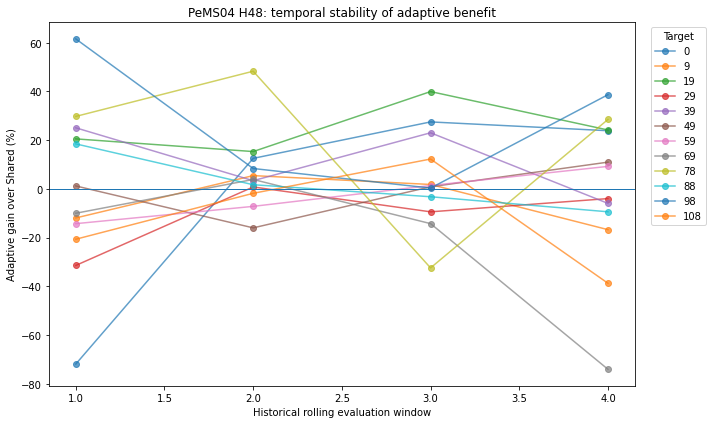

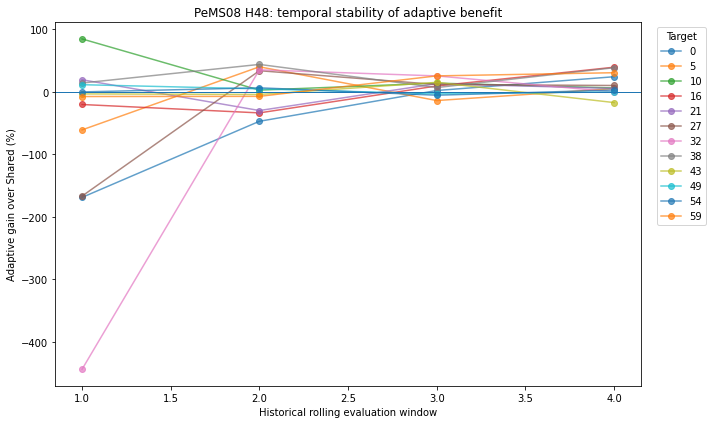

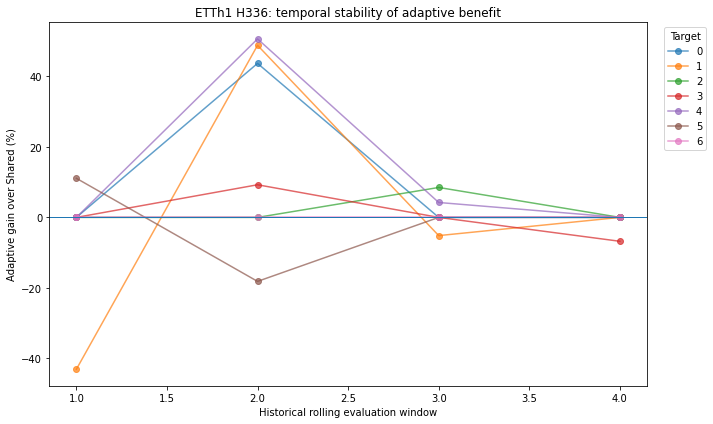

In [27]:
def plot_rolling_condition(
    dataset,
    horizon,
    max_targets=12,
):
    sub = rolling_all[
        (
            rolling_all[
                "dataset"
            ]
            ==
            dataset
        )
        &
        (
            rolling_all[
                "horizon"
            ]
            ==
            horizon
        )
    ].copy()

    targets = sorted(
        sub[
            "target_channel"
        ].unique()
        .tolist()
    )[
        :max_targets
    ]

    fig, ax = plt.subplots(
        figsize=(
            10,
            6,
        )
    )

    for target in targets:
        ss = sub[
            sub[
                "target_channel"
            ]
            ==
            target
        ].sort_values(
            "rolling_window"
        )

        ax.plot(
            ss[
                "rolling_window"
            ],
            ss[
                "rolling_adaptive_gain_%"
            ],
            marker="o",
            alpha=0.7,
            label=str(
                target
            ),
        )

    ax.axhline(
        0.0,
        linewidth=1,
    )

    ax.set_xlabel(
        "Historical rolling evaluation window"
    )

    ax.set_ylabel(
        "Adaptive gain over Shared (%)"
    )

    ax.set_title(
        f"{dataset} H{horizon}: temporal stability of adaptive benefit"
    )

    if len(
        targets
    ) <= 12:
        ax.legend(
            title="Target",
            bbox_to_anchor=(
                1.02,
                1.0,
            ),
            loc="upper left",
        )

    plt.tight_layout()
    plt.show()


for d, h in [
    (
        "PeMS04",
        48,
    ),
    (
        "PeMS08",
        48,
    ),
    (
        "ETTh1",
        336,
    ),
]:
    if (
        (
            rolling_all[
                "dataset"
            ]
            ==
            d
        )
        &
        (
            rolling_all[
                "horizon"
            ]
            ==
            h
        )
    ).any():
        plot_rolling_condition(
            d,
            h,
        )


## 27. Main performance plot


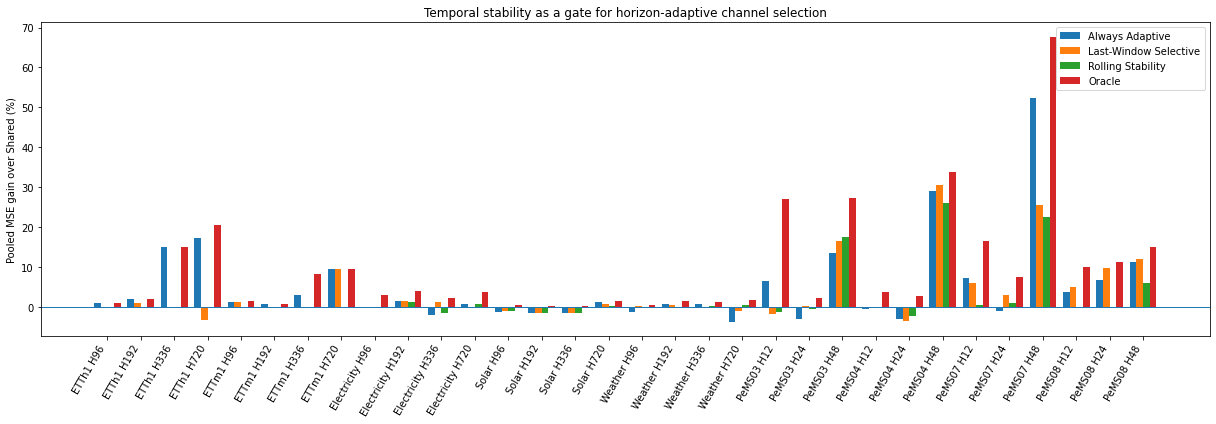

In [28]:
plot_df = paired.copy()

plot_df[
    "condition"
] = (
    plot_df[
        "dataset"
    ]
    +
    " H"
    +
    plot_df[
        "horizon"
    ].astype(str)
)

xpos = np.arange(
    len(
        plot_df
    )
)

width = 0.20

fig, ax = plt.subplots(
    figsize=(
        17,
        6,
    )
)

ax.bar(
    xpos
    -
    1.5
    *
    width,
    plot_df[
        "always_adaptive_gain_%"
    ],
    width,
    label="Always Adaptive",
)

ax.bar(
    xpos
    -
    0.5
    *
    width,
    plot_df[
        "last_window_gain_%"
    ],
    width,
    label="Last-Window Selective",
)

ax.bar(
    xpos
    +
    0.5
    *
    width,
    plot_df[
        "stability_gain_%"
    ],
    width,
    label="Rolling Stability",
)

ax.bar(
    xpos
    +
    1.5
    *
    width,
    plot_df[
        "oracle_gain_%"
    ],
    width,
    label="Oracle",
)

ax.axhline(
    0.0,
    linewidth=1,
)

ax.set_xticks(
    xpos
)

ax.set_xticklabels(
    plot_df[
        "condition"
    ],
    rotation=60,
    ha="right",
)

ax.set_ylabel(
    "Pooled MSE gain over Shared (%)"
)

ax.set_title(
    "Temporal stability as a gate for horizon-adaptive channel selection"
)

ax.legend()

plt.tight_layout()
plt.show()


## 28. Automatic decision report


In [29]:
n_conditions = len(
    paired
)

mean_stability = float(
    paired[
        "stability_gain_%"
    ].mean()
)

mean_last = float(
    paired[
        "last_window_gain_%"
    ].mean()
)

mean_always = float(
    paired[
        "always_adaptive_gain_%"
    ].mean()
)

mean_oracle = float(
    paired[
        "oracle_gain_%"
    ].mean()
)

n_positive = int(
    (
        paired[
            "stability_gain_%"
        ]
        >
        0
    ).sum()
)

n_beats_always = int(
    (
        paired[
            "stability_gain_%"
        ]
        >
        paired[
            "always_adaptive_gain_%"
        ]
    ).sum()
)

n_beats_last = int(
    (
        paired[
            "stability_gain_%"
        ]
        >
        paired[
            "last_window_gain_%"
        ]
    ).sum()
)

print(
    "="
    *
    80
)

print(
    "ROLLING TEMPORAL STABILITY GATE"
)

print(
    "="
    *
    80
)

print(
    f"Conditions: {n_conditions}"
)

print(
    f"Mean Always-Adaptive gain: {mean_always:+.3f}%"
)

print(
    f"Mean Last-Window gain:      {mean_last:+.3f}%"
)

print(
    f"Mean Stability gain:        {mean_stability:+.3f}%"
)

print(
    f"Mean Oracle gain:           {mean_oracle:+.3f}%"
)

print(
    f"Stability > Shared:         "
    f"{n_positive}/{n_conditions}"
)

print(
    f"Stability > Always:         "
    f"{n_beats_always}/{n_conditions}"
)

print(
    f"Stability > Last Window:    "
    f"{n_beats_last}/{n_conditions}"
)

print(
    "\nDecision:"
)

if (
    mean_stability > 0
    and
    n_positive
    >=
    0.60
    *
    n_conditions
    and
    n_beats_always
    >=
    0.60
    *
    n_conditions
    and
    n_beats_last
    >=
    0.55
    *
    n_conditions
):
    print(
        "A. TEMPORAL STABILITY IS A USEFUL GATING PRINCIPLE."
    )

    print(
        "Proceed to a forecasting model with target–horizon selective "
        "adaptive routing."
    )

elif (
    mean_oracle > 0.5
    and
    (
        mean_stability
        >
        mean_always
        or
        n_beats_always
        >=
        0.55
        *
        n_conditions
    )
):
    print(
        "B. PARTIAL SUPPORT."
    )

    print(
        "Temporal stability improves safety, but does not fully solve "
        "the target–horizon selection problem."
    )

    print(
        "Inspect whether persistent benefit is concentrated in PeMS / "
        "long horizons before building a neural selective router."
    )

else:
    print(
        "C. TEMPORAL STABILITY DOES NOT RESOLVE EXPLOITABILITY."
    )

    print(
        "Do not add another adaptive-routing architecture."
    )

    print(
        "Use the Oracle and rolling analyses to frame the empirical limits "
        "of horizon-specific channel selection."
    )


ROLLING TEMPORAL STABILITY GATE
Conditions: 32
Mean Always-Adaptive gain: +5.157%
Mean Last-Window gain:      +3.439%
Mean Stability gain:        +2.063%
Mean Oracle gain:           +9.471%
Stability > Shared:         13/32
Stability > Always:         11/32
Stability > Last Window:    11/32

Decision:
C. TEMPORAL STABILITY DOES NOT RESOLVE EXPLOITABILITY.
Do not add another adaptive-routing architecture.
Use the Oracle and rolling analyses to frame the empirical limits of horizon-specific channel selection.


# 29. How this experiment maps to the paper

If the stability gate works, the paper story becomes:

\[
\boxed{
\text{Horizon-dependent dependencies are common,
but only temporally persistent shifts should be exploited.}
}
\]

The method can then be motivated as

\[
\hat y_{i,h}
=
\hat y_{i,h}^{shared}
+
g_{i,h}
\Delta\hat y_{i,h}^{adaptive}
\]

where

\[
g_{i,h}
\]

is not an unconstrained learned switch.
It is grounded in historical evidence that adaptive source selection
repeatedly improved out-of-time forecasting for that target and horizon.

---

# Strong contribution structure if supported

### Observation 1
Cross-channel dependency changes with forecast horizon.

### Observation 2
Always adapting source channels is unreliable and can be catastrophic.

### Observation 3
The benefit is target- and horizon-specific.

### Observation 4
A single validation snapshot poorly predicts future exploitability.

### Observation 5
**Temporal persistence** provides a stronger criterion for deciding
whether horizon-adaptive routing should be activated.

This gives a considerably more precise message than:

> Different horizons need different channels.

The revised message is:

> **Different horizons may need different channels, but only when the
> predictive advantage of changing those channels persists over time.**

---

# If the gate fails

A failure is also informative.

If even a perfect historical-stability rule cannot reliably anticipate
test benefit, then horizon-adaptive channel selection is intrinsically
nonstationary under the current predictive-utility definition.

At that point the architecture search should stop, and the paper should
focus on the empirical distinction between:

\[
\text{dependency variation},
\quad
\text{predictive utility},
\quad
\text{temporal exploitability}.
\]

---

# Important protocol note

This notebook intentionally changes the source-selection size rule from the
previous fixed \(K=10\) screening to

\[
K(C)
=
\min
\left(
10,\left\lceil(C-1)/2\right\rceil
\right).
\]

Therefore the final Shared / Adaptive / Oracle numbers in this notebook are
a **fresh controlled evaluation** and should not be numerically mixed with
the previous fixed-\(K\) results.

The rule is fixed globally before examining the new test results.
